In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization, Flatten
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# PATIENT_COL = "Patient_ID"
# TIME_COL    = "Hour"
# TARGET_COL  = "SepsisLabel"

In [ ]:
df = pd.read_csv("/content/Dataset.csv")

# REQUIRED columns:
# Patient_ID, Hour, SepsisLabel + your features

In [ ]:
# --- 2. Paper's Feature Selection (90% Missing Value Rule) ---
# The paper removed 15 features that had at least 90% missing values
missing_threshold = 0.90
missing_fractions = df.isnull().mean()
cols_to_drop = missing_fractions[missing_fractions >= missing_threshold].index
df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns with >= 90% missing values.")

feature_cols = [col for col in df.columns if col not in ["Patient_ID", "Hour", "SepsisLabel"]]

Dropped 26 columns with >= 90% missing values.


In [ ]:
# --- 3. Patient-Wise Splitting (80/10/10) ---
patients = df["Patient_ID"].unique()
train_ids, temp_ids = train_test_split(patients, test_size=0.2, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

train_df = df[df["Patient_ID"].isin(train_ids)].copy()
val_df   = df[df["Patient_ID"].isin(val_ids)].copy()
test_df  = df[df["Patient_ID"].isin(test_ids)].copy()

In [ ]:
# --- 4. MICE Imputation (Iterative Imputer) ---
def paper_mice_impute(train, val, test, cols):
    # max_iter=10 is standard for MICE
    imputer = IterativeImputer(max_iter=10, random_state=42)

    # Fit on train, transform others to avoid data leakage
    train[cols] = imputer.fit_transform(train[cols])
    val[cols] = imputer.transform(val[cols])
    test[cols] = imputer.transform(test[cols])
    return train, val, test

train_df, val_df, test_df = paper_mice_impute(train_df, val_df, test_df, feature_cols)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
# train_df = paper_mice_impute(train_df, feature_cols)
# val_df   = paper_mice_impute(val_df, feature_cols)
# test_df  = paper_mice_impute(test_df, feature_cols)

# Call the function once with all three dataframes
train_df, val_df, test_df = paper_mice_impute(train_df, val_df, test_df, feature_cols)

In [ ]:
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols]   = scaler.transform(val_df[feature_cols])
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

In [ ]:
# --- 6. Windowing & Horizon Functions ---
def create_labels(df, h):
    df = df.sort_values(["Patient_ID", "Hour"]).copy()
    df["label_h"] = 0
    for pid, group in df.groupby("Patient_ID"):
        idx = group.index
        hours = group["Hour"].values
        labels = group["SepsisLabel"].values
        new_labels = []
        for i in range(len(hours)):
            future = (hours >= hours[i]) & (hours <= hours[i] + h)
            new_labels.append(1 if labels[future].max() == 1 else 0)
        df.loc[idx, "label_h"] = new_labels
    return df

In [ ]:
def build_windows(df, feature_cols, w):
    X, y = [], []
    for pid, group in df.groupby("Patient_ID"):
        values = group[feature_cols].values
        labels = group["label_h"].values
        for i in range(len(values)):
            start = max(0, i - w + 1)
            window = values[start:i+1]
            if len(window) < w:
                pad = np.tile(window[0], (w - len(window), 1))
                window = np.vstack([pad, window])
            X.append(window)
            y.append(labels[i])
    return np.array(X), np.array(y)

In [ ]:
# Set Paper Best: Observation Window (w=6), Horizon (h=1)
w, h = 6, 1
train_df = create_labels(train_df, h)
val_df   = create_labels(val_df, h)
test_df  = create_labels(test_df, h)

X_train, y_train = build_windows(train_df, feature_cols, w)
X_val, y_val     = build_windows(val_df, feature_cols, w)
X_test, y_test   = build_windows(test_df, feature_cols, w)

In [ ]:
# Flatten for SMOTE
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val), -1)

smote = SMOTE(random_state=42)

# Create the "res" (resampled) variables
X_train_res_flat, y_train_res = smote.fit_resample(X_train_flat, y_train)
X_val_res_flat, y_val_res     = smote.fit_resample(X_val_flat, y_val)

# Reshape back to 3D for the BiLSTM
X_train_res = X_train_res_flat.reshape(-1, w, len(feature_cols))
X_val_res   = X_val_res_flat.reshape(-1, w, len(feature_cols))

print("SMOTE Complete. Shapes:", X_train_res.shape, y_train_res.shape)

SMOTE Complete. Shapes: (2436386, 6, 15) (2436386,)


In [ ]:
# --- 8. The Paper's Best Model (BiLSTM 130) ---
model = Sequential([
    # BiLSTM layer with 130 neurons per direction, Tanh activation
    Bidirectional(LSTM(130, return_sequences=True, activation='tanh'), input_shape=(w, len(feature_cols))),
    Dropout(0.3),
    BatchNormalization(),
    Flatten(),
    # First Dense layer: 15 neurons, ELU activation
    Dense(15, activation='elu'),
    Dropout(0.5),
    # Output layer: Sigmoid
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# --- 9. Training ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Now y_train_res and X_train_res are defined!
history = model.fit(
    X_train_res, y_train_res,
    validation_data=(X_val_res, y_val_res),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
38069/38069 ━━━━━━━━━━━━━━━━━━━━ 1095s 29ms/step - accuracy: 0.8445 - auc: 0.9238 - loss: 0.3480 - val_accuracy: 0.6380 - val_auc: 0.7017 - val_loss: 2.0186
Epoch 2/50
38069/38069 ━━━━━━━━━━━━━━━━━━━━ 1081s 28ms/step - accuracy: 0.9381 - auc: 0.9818 - loss: 0.1627 - val_accuracy: 0.6004 - val_auc: 0.6641 - val_loss: 3.3193
Epoch 3/50
38069/38069 ━━━━━━━━━━━━━━━━━━━━ 1130s 29ms/step - accuracy: 0.9569 - auc: 0.9901 - loss: 0.1168 - val_accuracy: 0.5830 - val_auc: 0.6369 - val_loss: 4.4357
Epoch 4/50
38069/38069 ━━━━━━━━━━━━━━━━━━━━ 1124s 30ms/step - accuracy: 0.9653 - auc: 0.9932 - loss: 0.0949 - val_accuracy: 0.5786 - val_auc: 0.6358 - val_loss: 4.3134
Epoch 5/50
38069/38069 ━━━━━━━━━━━━━━━━━━━━ 1065s 28ms/step - accuracy: 0.9701 - auc: 0.9947 - loss: 0.0821 - val_accuracy: 0.5711 - val_auc: 0.6241 - val_loss: 4.6557
Epoch 6/50
38069/38069 ━━━━━━━━━━━━━━━━━━━━ 1067s 28ms/step - accuracy: 0.9731 - auc: 0.9956 - loss: 0.0738 - val_accuracy: 0.5702 - val_auc: 0.6175 - val_loss:

In [ ]:
# --- 10. Evaluation (Targeting SEN and AUC) ---
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\n--- Final Performance ---")
print(f"Sensitivity (SEN): {tp / (tp + fn):.4f}")
print(f"Specificity (SPE): {tn / (tn + fp):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Accuracy (ACC): {accuracy_score(y_test, y_pred):.4f}")

4892/4892 ━━━━━━━━━━━━━━━━━━━━ 34s 7ms/step

--- Final Performance ---
Sensitivity (SEN): 0.3606
Specificity (SPE): 0.8629
AUC: 0.6823
Accuracy (ACC): 0.8519


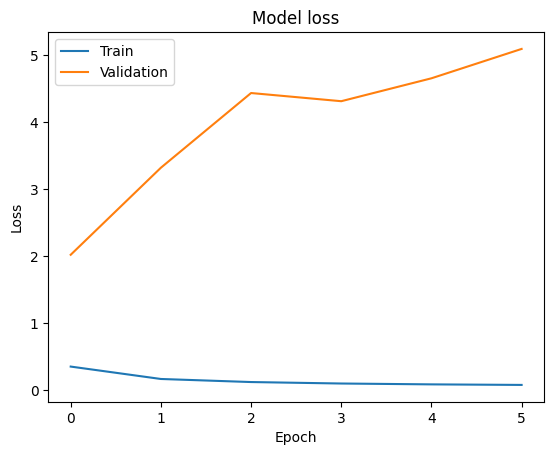

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
def compute_saliency(model, sample):
    """
    sample shape: (timesteps, features)
    """
    sample_tensor = tf.convert_to_tensor(sample[np.newaxis, ...], dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(sample_tensor)
        prediction = model(sample_tensor)
        output = prediction[:, 0]

    gradients = tape.gradient(output, sample_tensor)
    saliency = tf.abs(gradients).numpy()[0]

    return saliency, prediction.numpy()[0][0]

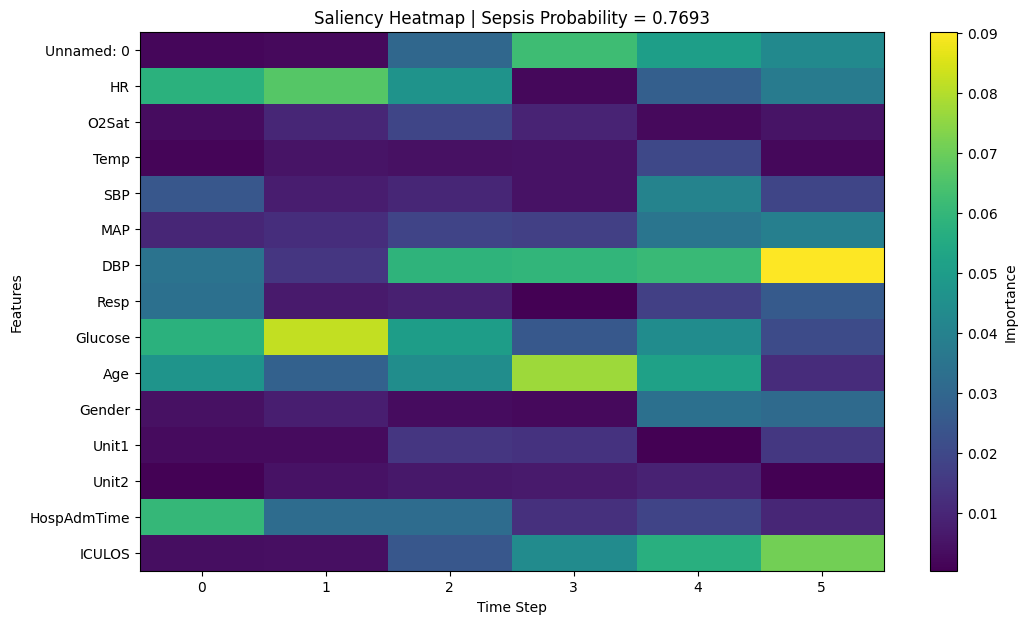

,Feature,Importance
6,DBP,0.053140
8,Glucose,0.046618
9,Age,0.043306
1,HR,0.039671
14,ICULOS,0.034040
0,Unnamed: 0,0.031791
13,HospAdmTime,0.027677
5,MAP,0.022033
4,SBP,0.017763
7,Resp,0.015285


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

feature_names = list(feature_cols)

idx = 0
sample = X_test[idx]

sample_tensor = tf.convert_to_tensor(sample[np.newaxis, ...], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(sample_tensor)
    pred = model(sample_tensor)
    output = pred[:, 0]

grads = tape.gradient(output, sample_tensor)
saliency = tf.abs(grads).numpy()[0]
pred_prob = pred.numpy()[0][0]

plt.figure(figsize=(12, 7))
plt.imshow(saliency.T, aspect="auto")
plt.colorbar(label="Importance")
plt.xlabel("Time Step")
plt.ylabel("Features")
plt.yticks(range(len(feature_names)), feature_names)
plt.title(f"Saliency Heatmap | Sepsis Probability = {pred_prob:.4f}")
plt.show()

saliency_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.mean(saliency, axis=0)
}).sort_values("Importance", ascending=False)

display(saliency_df.head(15))

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_16
Received: inputs=['Tensor(shape=(20, 6, 15))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_16
Received: inputs=['Tensor(shape=(50, 6, 15))']
  warnings.warn(msg)


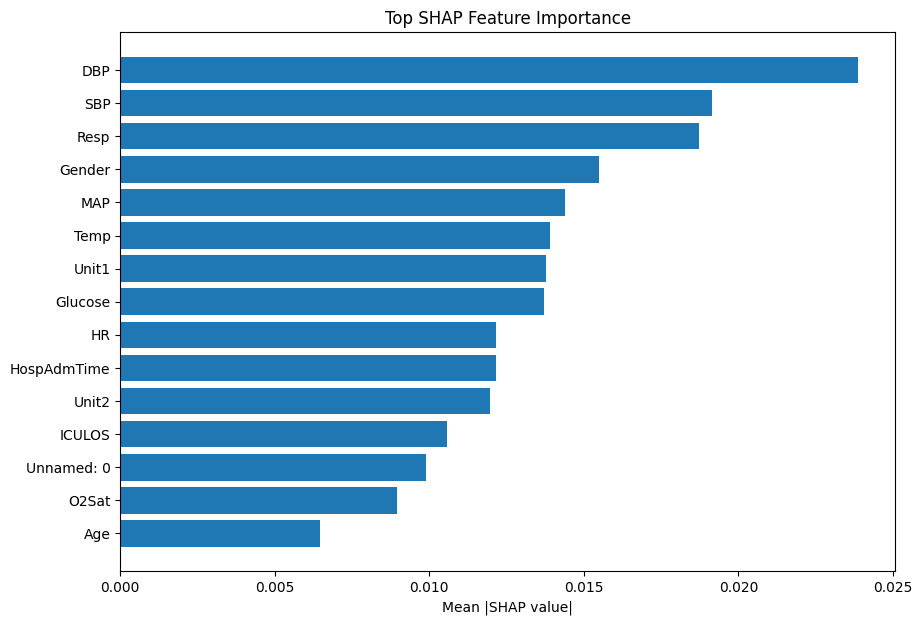

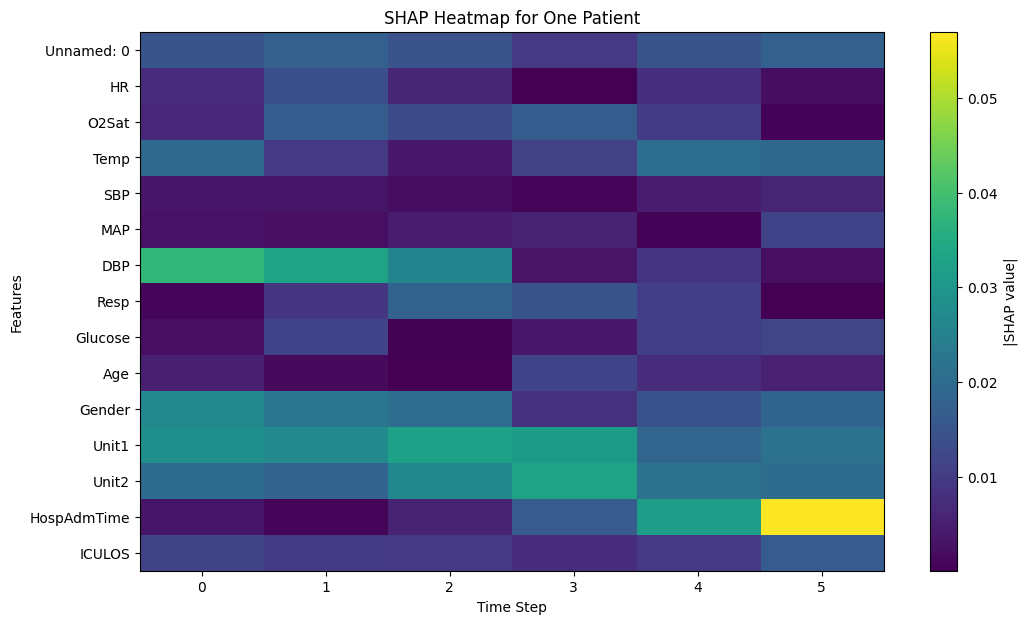

,Feature,Mean_SHAP
6,DBP,0.023881
4,SBP,0.019131
7,Resp,0.018735
10,Gender,0.015497
5,MAP,0.014395
3,Temp,0.013909
11,Unit1,0.013774
8,Glucose,0.013698
1,HR,0.012152
13,HospAdmTime,0.012143


In [ ]:
!pip install shap -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = list(feature_cols)

background_size = min(100, X_train.shape[0])
test_size = min(20, X_test.shape[0])

background_idx = np.random.choice(X_train.shape[0], background_size, replace=False)
background = X_train[background_idx]
test_samples = X_test[:test_size]

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_samples)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

mean_shap = np.mean(np.abs(shap_values), axis=(0, 1))

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": mean_shap.flatten()
}).sort_values("Mean_SHAP", ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(shap_importance["Feature"].head(15), shap_importance["Mean_SHAP"].head(15))
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value|")
plt.title("Top SHAP Feature Importance")
plt.show()

idx = 0
patient_shap = shap_values[idx]

plt.figure(figsize=(12, 7))
plt.imshow(np.abs(patient_shap).squeeze().T, aspect="auto")
plt.colorbar(label="|SHAP value|")
plt.xlabel("Time Step")
plt.ylabel("Features")
plt.yticks(range(len(feature_names)), feature_names)
plt.title("SHAP Heatmap for One Patient")
plt.show()

display(shap_importance.head(15))

In [ ]:
!pip install lime -q

import numpy as np
from lime import lime_tabular

feature_names = list(feature_cols)

n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

X_train_flat = X_train.reshape(X_train.shape[0], n_timesteps * n_features)
X_test_flat = X_test.reshape(X_test.shape[0], n_timesteps * n_features)

lime_feature_names = []

for t in range(n_timesteps):
    for f in feature_names:
        lime_feature_names.append(f"{f}_t{t}")

def predict_lime(x_flat):
    x_3d = x_flat.reshape(x_flat.shape[0], n_timesteps, n_features)
    probs = model.predict(x_3d, verbose=0)
    return np.hstack([1 - probs, probs])

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_flat,
    feature_names=lime_feature_names,
    class_names=["Non-Sepsis", "Sepsis"],
    mode="classification"
)

idx = 0

lime_exp = lime_explainer.explain_instance(
    X_test_flat[idx],
    predict_lime,
    num_features=15
)

lime_exp.show_in_notebook(show_table=True)

lime_exp.save_to_file("lime_bilstm_explanation.html")

print("Saved: lime_bilstm_explanation.html")
print(lime_exp.as_list())

Saved: lime_bilstm_explanation.html
[('ICULOS_t2 <= -0.65', -0.02330154844500722), ('HospAdmTime_t3 <= 0.06', -0.01933606514568771), ('ICULOS_t3 <= -0.61', -0.016686243062496563), ('HospAdmTime_t1 <= 0.06', -0.014940931550036481), ('ICULOS_t4 <= -0.58', -0.014650775469099991), ('Unnamed: 0_t2 <= -0.67', -0.0137416337711975), ('Gender_t4 <= -1.12', 0.011112346426776158), ('0.01 < Glucose_t2 <= 0.31', -0.010175707260368398), ('HospAdmTime_t2 <= 0.06', -0.009976554386323961), ('-0.44 < O2Sat_t0 <= 0.07', 0.009895601135841448), ('-0.63 < Age_t0 <= 0.12', -0.009230199237375367), ('-0.06 < MAP_t5 <= 0.49', -0.009041165649449791), ('-0.11 < Resp_t1 <= 0.27', 0.008877440581730818), ('Unit2_t4 <= -1.29', 0.008558957043093748), ('-0.04 < HR_t1 <= 0.51', 0.008153729993068808)]


In [ ]:
# def permutation_importance_bilstm(model, X_test, y_test, feature_cols, w=6):
#     model.eval()

#     X_np = X_test.numpy()
#     y_np = y_test.numpy()

#     base_probs = model(X_test).detach().numpy()
#     base_auc = roc_auc_score(y_np, base_probs)

#     importances = []

#     for f in range(len(feature_cols)):
#         X_perm = X_np.copy()

#         for t in range(w):
#             vals = X_perm[:, t, f]
#             np.random.shuffle(vals)
#             X_perm[:, t, f] = vals

#         probs = model(torch.tensor(X_perm, dtype=torch.float32)).detach().numpy()
#         auc_score = roc_auc_score(y_np, probs)

#         importances.append((feature_cols[f], base_auc - auc_score))

#     df_imp = pd.DataFrame(importances, columns=["Feature", "Importance"])
#     return df_imp.sort_values("Importance", ascending=False)

# importance_df = permutation_importance_bilstm(model, X_test, y_test, feature_cols)
# importance_df.head(10)

In [ ]:
# top_k = 15
# df_plot = importance_df.head(top_k)

# plt.figure(figsize=(8,6))
# plt.barh(df_plot["Feature"], df_plot["Importance"])
# plt.gca().invert_yaxis()

# plt.xlabel("Importance (AUC drop)")
# plt.title("Top Features")
# plt.show()

In [ ]:
# X_train, y_train = build_3d_windows(train_df, feature_cols, w=6)
# X_val, y_val     = build_3d_windows(val_df, feature_cols, w=6)
# X_test, y_test   = build_3d_windows(test_df, feature_cols, w=6)

In [ ]:
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset

# X_train = torch.tensor(X_train, dtype=torch.float32)
# y_train = torch.tensor(y_train, dtype=torch.float32)

# X_val = torch.tensor(X_val, dtype=torch.float32)
# y_val = torch.tensor(y_val, dtype=torch.float32)

# X_test = torch.tensor(X_test, dtype=torch.float32)
# y_test = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
# class BiLSTM(nn.Module):
#     def __init__(self, input_size):
#         super().__init__()

#         self.lstm = nn.LSTM(
#             input_size=input_size,
#             hidden_size=130,   # paper
#             batch_first=True,
#             bidirectional=True
#         )

#         self.bn = nn.BatchNorm1d(260)

#         self.fc1 = nn.Linear(260, 15)  # paper
#         self.elu = nn.ELU()

#         self.dropout = nn.Dropout(0.5)

#         self.fc2 = nn.Linear(15, 1)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         out, _ = self.lstm(x)

#         out = out[:, -1, :]   # last timestep

#         out = self.bn(out)

#         out = self.fc1(out)
#         out = self.elu(out)

#         out = self.dropout(out)

#         out = self.fc2(out)
#         out = self.sigmoid(out)

#         return out.squeeze()

In [ ]:
# model = BiLSTM(input_size=len(feature_cols))

# criterion = nn.BCELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# train_loader = DataLoader(
#     TensorDataset(X_train, y_train),
#     batch_size=64,
#     shuffle=True
# )

# val_loader = DataLoader(
#     TensorDataset(X_val, y_val),
#     batch_size=64
# )

In [ ]:
# best_val_loss = float("inf")
# patience = 5
# counter = 0

# for epoch in range(50):  # paper uses early stopping
#     model.train()
#     train_loss = 0

#     for xb, yb in train_loader:
#         optimizer.zero_grad()

#         preds = model(xb)
#         loss = criterion(preds, yb)

#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()

#     # validation
#     model.eval()
#     val_loss = 0

#     with torch.no_grad():
#         for xb, yb in val_loader:
#             preds = model(xb)
#             loss = criterion(preds, yb)
#             val_loss += loss.item()

#     print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         counter = 0
#         best_weights = model.state_dict()
#     else:
#         counter += 1
#         if counter >= patience:
#             print("Early stopping triggered")
#             break

# model.load_state_dict(best_weights)

In [ ]:
# from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score

# model.eval()

# with torch.no_grad():
#     probs = model(X_test).numpy()

# preds = (probs >= 0.5).astype(int)

# tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

# sen = tp / (tp + fn + 1e-8)
# spe = tn / (tn + fp + 1e-8)
# acc = accuracy_score(y_test, preds)
# auc = roc_auc_score(y_test, probs)

# print(f"SEN={sen:.3f}")
# print(f"SPE={spe:.3f}")
# print(f"ACC={acc:.3f}")
# print(f"AUC={auc:.3f}")

curves

In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import roc_auc_score

In [ ]:
# def permutation_importance_bilstm(model, X_test_3d, y_test, feature_cols, w=6, n_repeats=3):
#     model.eval()

#     # baseline
#     with torch.no_grad():
#         base_probs = model(torch.tensor(X_test_3d, dtype=torch.float32)).numpy()

#     base_auc = roc_auc_score(y_test, base_probs)

#     importances = []

#     n_features = len(feature_cols)

#     for f in range(n_features):
#         scores = []

#         for _ in range(n_repeats):
#             X_perm = X_test_3d.copy()

#             # permute feature across ALL timesteps
#             for t in range(w):
#                 col_idx = f
#                 vals = X_perm[:, t, col_idx].copy()
#                 np.random.shuffle(vals)
#                 X_perm[:, t, col_idx] = vals

#             with torch.no_grad():
#                 probs = model(torch.tensor(X_perm, dtype=torch.float32)).numpy()

#             auc_score = roc_auc_score(y_test, probs)
#             scores.append(base_auc - auc_score)

#         importances.append({
#             "Feature": feature_cols[f],
#             "Importance": np.mean(scores)
#         })

#     df_imp = pd.DataFrame(importances).sort_values(by="Importance", ascending=False)
#     return df_imp

In [ ]:
# importance_df = permutation_importance_bilstm(
#     model,
#     X_test_3d,
#     y_test,
#     feature_cols,
#     w=6
# )

# importance_df.head(10)

In [ ]:
# plt.figure(figsize=(8,6))

# top_k = 15
# df_plot = importance_df.head(top_k)

# plt.barh(df_plot["Feature"], df_plot["Importance"])
# plt.gca().invert_yaxis()

# plt.xlabel("Importance (AUC drop)")
# plt.title("Top Features (Permutation Importance)")

# plt.show()